# Polynomial

## import packages

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Read datas 

In [53]:
data = pd.read_csv('FuelConsumption.csv')
data

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


## Choose Special Column of Data

In [54]:
c_data = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
c_data

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


## visualize Datas

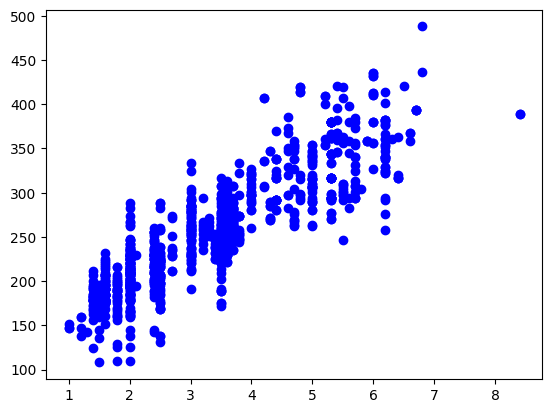

In [55]:
plt.scatter(c_data.ENGINESIZE, c_data.CO2EMISSIONS, color='blue')

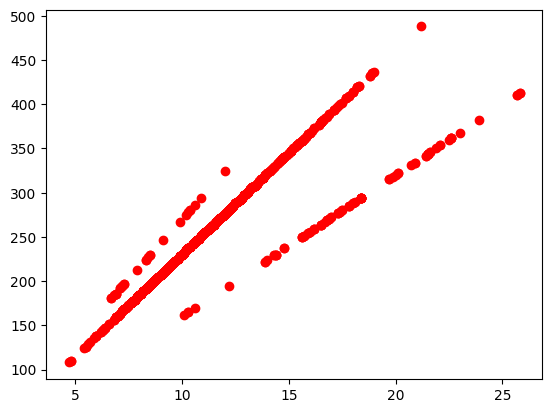

In [56]:
plt.scatter(c_data.FUELCONSUMPTION_COMB, c_data.CO2EMISSIONS, color='red')

## Create Test and Train datas

In [70]:
mask = np.random.rand(len(data)) < 0.8
train = c_data[mask]
test = c_data[~mask]
train, test

(      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
 1            2.4          4                   9.6           221
 2            1.5          4                   5.9           136
 3            3.5          6                  11.1           255
 6            3.5          6                  10.1           232
 7            3.7          6                  11.1           255
 ...          ...        ...                   ...           ...
 1062         3.0          6                  11.8           271
 1063         3.2          6                  11.5           264
 1064         3.0          6                  11.8           271
 1065         3.2          6                  11.3           260
 1066         3.2          6                  12.8           294
 
 [879 rows x 4 columns],
       ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
 0            2.0          4                   8.5           196
 4            3.5          6                  10.6           24

## Modeling

In [71]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

poly = PolynomialFeatures(degree=4)
train_x_poly = poly.fit_transform(train_x)
train_x_poly

array([[  1.    ,   2.4   ,   5.76  ,  13.824 ,  33.1776],
       [  1.    ,   1.5   ,   2.25  ,   3.375 ,   5.0625],
       [  1.    ,   3.5   ,  12.25  ,  42.875 , 150.0625],
       ...,
       [  1.    ,   3.    ,   9.    ,  27.    ,  81.    ],
       [  1.    ,   3.2   ,  10.24  ,  32.768 , 104.8576],
       [  1.    ,   3.2   ,  10.24  ,  32.768 , 104.8576]])

In [72]:
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

In [73]:
mdl = linear_model.LinearRegression()
train_y_ = mdl.fit(train_x_poly, train_y)

print(f'Coefs: {mdl.coef_}')
print(f'Intercept: {mdl.intercept_}')

Coefs: [[ 0.00000000e+00  3.35389775e+01  2.10776241e+00 -3.22716444e-02
  -3.14802200e-02]]
Intercept: [127.71877636]


## Output

In [74]:
from sklearn.metrics import r2_score

test_x_poly = poly.fit_transform(test_x)
test_y_ = mdl.predict(test_x_poly)

print(f'R2: {r2_score(test_y, test_y_)}')

R2: 0.7901095498928845


Text(0, 0.5, 'Emission')

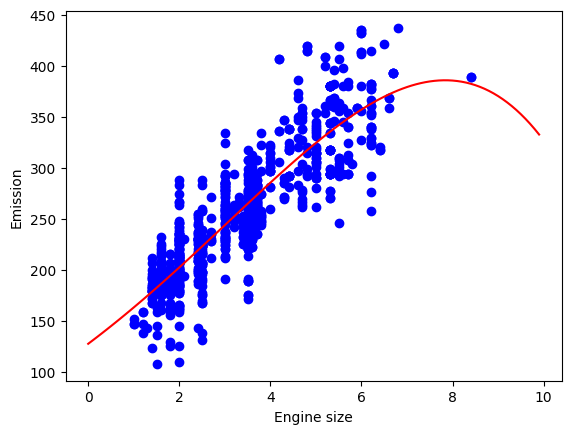

In [77]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
XX = np.arange(0.0, 10.0, 0.1)
yy = mdl.intercept_[0]+ mdl.coef_[0][1]*XX + mdl.coef_[0][2] * np.power(XX, 2) +  mdl.coef_[0][3] * np.power(XX, 3) + mdl.coef_[0][4] * np.power(XX, 4)
plt.plot(XX, yy, '-r' )
plt.xlabel("Engine size")
plt.ylabel("Emission")

## SELF TEST

In [79]:
test = [[5.9]]
test_poly = poly.fit_transform(test)
mdl.predict(test_poly)

array([[354.1963161]])